In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ridge_regression

In [26]:
def l2_regularization(alpha, weights):
    return alpha * sum(abs(weight) for weight in weights)

def mean_squered_error(y, y_hat):
    return sum([(i - j)**2 for i, j in zip(y, y_hat)]) / len(y)

In [27]:
class ridge_red:
    
    def __init__(self, alpha=1, learning_rate=0.01, max_iter=100, model="iterative"):
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.model = model

    def fit(self, X, y):

        if self.model == "closed-form":
            self.weights = np.inv(X.T @ X + self.alpha * np.eye(X.shape[1])) @ (X.T @ y)

        else:
            self.weights = np.zeros((X.shape[1], 1))

            for _ in range(self.max_iter):

                error = X @ self.weights - y
                dw = X.T @ error + self.alpha * self.weights
 
                self.weights -= self.learning_rate * dw

    def predict(self, X):
        return X @ self.weights
    
    def __repr__(self):
        
        if self.model == "closed-form":
            solver = "closed"
        else:
            solver = "gd"

        return f"ridge with alpha:{self.alpha}, lr:{self.learning_rate}, solver: {solver}"

In [30]:
np.random.seed(56)

X_train = np.linspace(-10, 10, 50)
y_train = 100 * X_train + 2
X_train = X_train.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)

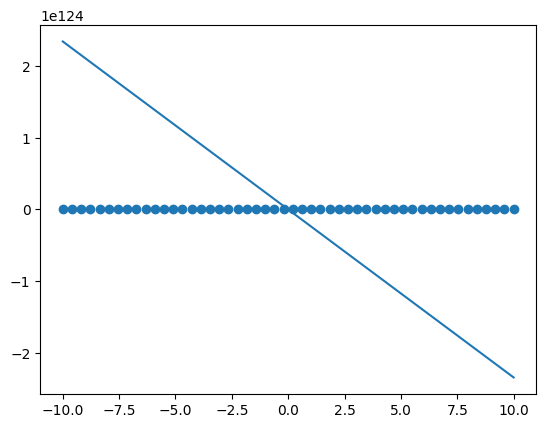

In [31]:
model = ridge_red()
model.fit(X_train, y_train)

plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train));